# A projekt tartalma:
* 1. rész: külső adatforrás feldolgozása és vektortérbe beágyazása, vektoradatbázis létrehozása / betöltése
* 2. rész: agent felépítése és a tool-jainak az implementálása
* 3. rész: az agent meghívása

### importok:

In [1]:
from IPython.display import Image, display
import os
from dotenv import load_dotenv
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph, add_messages
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from google import genai
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_qdrant import QdrantVectorStore
from langchain_community.document_loaders import PyPDFDirectoryLoader

## 1. rész: Adatfeldolgozás és vektoradatbázis létrehozása / betöltése
Az első szekció négy nagy logikai egységből áll, és ezek együtt építik fel a teljes RAG‑rendszer alapját: a környezet betöltését, a konfigurációt, az embedding modellt, a vektoradatbázis létrehozását vagy betöltését, majd a retrievert.


#### 1. Environment & Configuration

- `load_dotenv()`: Betölti a `.env` fájlból az LLM API kulcsot, ami ebben az esetben `GOOGLE_API_KEY`, de lehetne akár bármi más, például `GROQ_API_KEY` is. Azért ezeket az LLM-eket használtam, mert ezek amellett, hogy kellő gyorsasággal futnak és a toolkezeléshez is elég "okosak", még ingyenesek is egy viszonylag szűk limitig.

- `DATA_DIR`: A mappa elérési helye, amiben a betölteni kívánt PDF vagy PDF-ek vannak. Azért választottam ezt, hogy egy egész mappát töltök be, hogy könnyen hozzáadható lehessen több PDF is, mint adatforrás.

- `QDRANT_PATH`: A Qdrant vektoradatbázis mentési helye. Azért fontos, hogy el legyen mentve, mert anélkül minden futásnál újra kéne építeni.

- `COLLECTION_NAME`: A Qdrant minden vektort collection-ben tárol, ezt a pdf-et pedig a `stock_market` nevűben tárolja. Ez tehát egy adattárolási egysége a vektoradatbázisnak.

- `CHUNK_SIZE = 1000`: A dokumentumot 1000 karakteres szövegrészekre, azaz chunk-okra vágja fel. Minden ilyen rész külön embedding-et kap, azaz külön vektorként kerül a Qdrant vektoradatbázisba. A chunk mérete meghatározza, hogy mennyire részletes a keresés (kisebb chunk-ok esetén pontosabbak a találatok), mennyire koherens a kontextus (nagyobb chunk-ok esetén több összefüggő információ lesz egy adott chunk-ban), és hogy milyen gyors a retriever (kevesebb chunk esetén gyorsabb a keresés). Azért ezt az 1000-es méretet választottam, mert ez egy általánosan bevált kompromisszum: elég nagy ahhoz, hogy értelmes kontextust adjon, de elég kicsi ahhoz, hogy releváns találatokat adjon vissza.

- `CHUNK_OVERLAP = 200`: Ez azt szabályozza, hogy a dokumentum feldarabolásakor a chunk-ok mekkora átfedésben legyenek egymással, azaz minden 1000 karakteres chunk 200 karaktert megoszt a következő chunk-kal. Ez a RAG-rendszer egyik kulcsparamétere, mert közvetlenül befolyásolja a visszakeresés pontosságát és a kontextus folytonosságát. Túl kicsi overlap (pl. 50) esetén szétesett lesz a kontextus, és rosszabb a retriever. Túl nagy overlap (pl. 400–500) esetén viszont sok lesz a duplikált chunk, így lassabb lesz a keresés. A 200‑as érték ebben az esetben is a gyakorlatban bevált, kiegyensúlyozott beállítás.

- `EMBED_MODEL`: Ez az embedding modell típusa. Erről részletesebben írok a következő pontban.

#### 2. Embedding Model

- `embeddings = HuggingFaceEmbeddings(model_name=EMBED_MODEL)`: Az embedding (vagy beágyazás) szerepe a chunk-okból numerikus vektorok létrehozása, amelyek beágyazhatóak majd a vektoradatbázisba, és ezek a beágyazott vektorok lesznek a beágyazások, vagy embedding-ek. A chunk-okat a `RecursiveCharacterTextSplitter` fogja létrehozni a szövegből, annak feldarabolásával, és ezek a feldarabolt kicsi részek a chunk-ok. Minél hasonlóbb egy-egy chunk jelentésileg, annál hasonlóbb vektorokat rendel hozzájuk az embedding modell. A vektorokká alakítás minősége tehát nagyon fontos, mert ennek a minősége közvetlenül meghatározza a keresés pontosságát. Azért a `HugingFaceEmbeddings`-t választottam, mert ez ingyenes, nem kell hozzá API-key, és nem kell külön paraméterezni. Egy ilyen bemutató projekthez pont ideálisnak gondoltam. Az `all‑MiniLM‑L6‑v2`-t pedig azért választottam, mert ez a egy általánosan bevált modell, kicsi (így alacsony a memóriaigénye és CPU-n is gyorsan fut) és mégis nagyon hatékony embedding modell, jó minőségű embedding-eket készít (megőrzi a szöveg szemantikai tartalmát). A MiniLM család különösen jó általános szövegfeldolgozási feladatokra, például PDF alapú RAG‑hez.

#### 3. Vector Store: Load or Create

- Itt betöltöm / létrehozom a teljes vektoradatbázist a chunk-okra feldarabolt PDF-ből és az embedding modellből. Itt épül fel az a tudásbázis, amelyből a retriever később keresni fog. Qdrant vektoradatbázist használok, mivel ez ingyenes, lokálisan is futtatható, és különösen előnyös skálázhatósági szempontból. Eleinte Chroma vektoradatbázist használtam, mivel az is könnyen használható (nem kell paraméterezni, lokálisan fut, így nem kell hozzá API-kulcs), ingyenes, és az ehhez hasonló kicsi-közepes méretű bemutató projektekhez ideális, de a skálázhatóság miatt a Qdrant mellett döntöttem, mivel a Chroma nagy mennyiségű tudásanyag tárolására már nem igazán jó. 

- A `load_existing_vectorstore()` metódusban a már létező Qdrant vektoradatbázist betöltöm, míg a `create_vectorstore_from_directory()` metódusban létrehozok egy új Qdrant vektoradatbázist és a `DATA_DIR` mappa PDF fájljait ágyazom bele. Ebben az esetben én csak egyetlen PDF-et használtam, mivel ahogy írtátok a feladatban, a mennyiség nem fontos, viszont skálázhatóság szempontjából előnyösebbnek gondoltam ezt a megoldást, mintha csak konkrétan egyetlen PDF-et olvasnék be, hiszen így ha bővíteni szeretnénk a tudásbázist, elég csak beletenni a mappába a további PDF-eket. A létrehozáskor a `RecursiveCharacterTextSplitter(...)`-t is meghívom, amely a chunk-olást  végzi, azaz a szöveget feldarabolja a korábban már leírt módon, és ezeket a chunk-okat adja át az embedding modellnek, amely pedig numerikus vektorokká alakítja ugye, és azok raktározódnak el a Qdrant-ban.

#### 4. Retriever
- Ez a rész a vektortárból egy keresőmotort (retrievert) készít, amelyet a RAG‑agent használ a releváns PDF‑részletek visszakeresésére.

- A `vectorstore.as_retriever()` létrehoz egy retriever objektumot, amely képes a felhasználói kérdést embeddinggé alakítani és hasonlóság alapján megkeresni a legközelebbi chunk-okat a ChromaDB‑ben. A `search_type="similarity"` által koszinusz-hasonlóság alapján rendezi a találatokat, a `k=5` által pedig a retriever az 5 legrelevánsabb chunk-ot adja vissza minden kérdésre.

### Összegzés

Az első szekció egy komplett RAG‑pipeline alapját építi fel:

- Konfiguráció: minden paraméter egy helyen, könnyen módosítható.

- Embedding modell: a szöveg numerikus reprezentációja.

- Vektortár: a dokumentumok hosszú távú, gyors keresésre optimalizált tárolása.

- Retriever: a keresőmotor, amely releváns kontextust ad az LLM‑nek.


In [2]:
# ---------------------------------------------------------
# 1. Environment & Configuration
# ---------------------------------------------------------

load_dotenv()  # Loads GOOGLE_API_KEY if needed

DATA_DIR = "./data"
QDRANT_PATH = "./qdrant_db"
COLLECTION_NAME = "stock_market"

CHUNK_SIZE = 1000
CHUNK_OVERLAP = 200
EMBED_MODEL = "all-MiniLM-L6-v2"


# ---------------------------------------------------------
# 2. Embedding Model
# ---------------------------------------------------------

print("Loading local HuggingFace embeddings...")
embeddings = HuggingFaceEmbeddings(model_name=EMBED_MODEL)


# ---------------------------------------------------------
# 3. Vector Store: Load or Create
# ---------------------------------------------------------

def load_existing_vectorstore():
    print("Vector store already exists. Loading existing database...")
    return QdrantVectorStore.from_existing_collection(
        embedding=embeddings,
        collection_name=COLLECTION_NAME,
        path=QDRANT_PATH
    )


def create_vectorstore_from_directory():
    print(f"Creating new vector store from PDFs in {DATA_DIR}...")

    # Safety check for the data directory
    if not os.path.exists(DATA_DIR):
        os.makedirs(DATA_DIR)
        raise FileNotFoundError(f"Directory not found. Created '{DATA_DIR}'. Please add PDFs and run again.")

    # Loads all PDFs in the folder
    loader = PyPDFDirectoryLoader(DATA_DIR)
    pages = loader.load()

    if not pages:
        raise ValueError(f"No readable PDFs found in '{DATA_DIR}'!")

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=CHUNK_SIZE,
        chunk_overlap=CHUNK_OVERLAP
    )
    chunks = splitter.split_documents(pages)

    os.makedirs(QDRANT_PATH, exist_ok=True)

    # Initialize and populate Qdrant
    vectorstore = QdrantVectorStore.from_documents(
        documents=chunks,
        embedding=embeddings,
        path=QDRANT_PATH,
        collection_name=COLLECTION_NAME
    )

    print("Created and saved Qdrant vector store!")
    return vectorstore

# Decide whether to load or create
vectorstore = load_existing_vectorstore() if os.path.exists(QDRANT_PATH) and os.listdir(QDRANT_PATH) else create_vectorstore_from_directory()


# ---------------------------------------------------------
# 4. Retriever
# ---------------------------------------------------------

retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 5}
)

print("Cell 1 Complete. Ready to build the graph!")


Loading local HuggingFace embeddings...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4889.24it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Vector store already exists. Loading existing database...
Cell 1 Complete. Ready to build the graph!


## 2. rész: Agent szerkezetének felépítése és a tool-jainak az implementálása
A második szekció a teljes agentikus RAG‑rendszer intelligenciáját építi fel: itt kapcsolódik össze a nyelvi modell, a tool-ok és a LangGraph agent szerkezete. Ez a rész felel azért, hogy a chatbot ne csak szöveget generáljon, hanem döntéseket hozzon, tool-okat használjon, és több lépésben "gondolkodjon".

#### 1. LLM Initialization

Ez a rész betölti a nyelvi modellt, amely az egész agentic RAG‑rendszer „agya”. A `ChatGoogleGenerativeAI(...)` a Gemini‑modellt csomagolja be úgy, hogy a LangChain és a LangGraph használni tudja. A `model` értelemszerűen a használt modell neve, a `temperature=0` által pedig a válaszok amennyire csak lehet determinisztikusak lesznek (ugyanarra a kérdésre ugyanazt fogja válaszolni az LLM).

Ezek miatt választottam Gemini modellt:

* Nagyon stabil és megbízható a toolkezelésben (nem keveri össze, hogy mikor kell a retriever és mikor a web_search toolt hívnia).

* A reasoning (érvelés) képessége is tökéletes ehhez a projekthez.

* Gyorsan válaszol, és egy (viszonylag szűk) limitig ingyenes is.

* Tökéletesen illeszkedik az ilyen single-agent állapotgép alapú rendszerekhez, mint amilyen ez is (a LangGraph által alkotott gráf egy véges determinisztikus állapotgépként (vagy véges determinisztikus automataként) fogható fel - angolul finite state machine).

Alternatívaként próbálkoztam lokális futtatású LLM-mel is Ollama által, abban `llama3.1:8b` modellt használtam, de rendkívül lassú és megbízhatatlan volt a toolkezelése (például olyankor is a retriever tool-t hívta, amikor egyértelműen egy most aktuális eseményre kérdeztem rá).

#### 2. Tools
A LangGraph tool-jait `@tool` dekorátorral kell ellátni, és nagyon fontos, hogy docstring-ben meg legyen fogalmazva az adott tool feladata, mert ez alapján tudja az LLM, hogy mire és mikor használja ezt a tool-t. (https://docs.langchain.com/oss/python/langchain/tools)

`retriever_tool(...)`: 
- A retriever_tool szerepe az, hogy az agent számára egy használható, jól formázott PDF‑kereső eszközt adjon, amelyet a modell meg tud hívni.

- Ez a RAG-modell magja, enélkül az agent nem férne hozzá a PDF‑hez. A modell automatikusan felismeri, hogy mikor kell ezt a toolt hívnia.

- A működése során először a user input-ot beágyazza a vektortérbe, a hozzá leghasonlóbb 5 db chunk-ot kiválasztja, ezeket visszaadja és visszaalakítja szöveges formátumra. Végül a tool output-ja bekerül az agent állapotába, majd az LLM újra fut, immár a PDF‑ből visszahozott tartalommal.

`web_search_tool(...)`:
- Ez a tool azért van a rendszerben, hogy ha az LLM a saját tudása és a PDF alapján sem tudja megválaszolni a kérdést, akkor is képes legyen webes kereséssel releváns információval szolgálni (ez a web fallback). 

- Így a chatbot naprakész információkat ad vissza, nem fogja azt válaszolni, hogy nem tudja, és nem is fog feleslegesen webes keresést alkalmazni (ehhez persze szükséges, hogy az LLM toolkezelése kellően okos legyen). 

- Azért DuckDuckGo keresőt használok, mert ez is API key nélkül használható, ingyenes, nincs felhasználási limitje (mint ahogyan mondjuk a Gemini modelleknek viszont van), és egyszerű, rövid szövegként adja vissza a találatot, könnyen integrálható LangChain-nel, LangGraph-fal, hiszen nem szükséges semmilyen konfiguráció a használatához, valamint adatvédelmi szempontból is az egyik legbiztonságosabb.

`tools`: 
- A LLM „tudomására hozza”, hogy milyen eszközök állnak rendelkezésére.

- A modell ezután képes automatikusan tool‑hívásokat generálni.

- Ez teszi a chatbotot agentic-ké, így a modell nem csak szöveget generál, hanem döntéseket hoz: „Most eszközt kell használnom.”

#### 3. Agent State definiálása

`class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]`:

- Meghatározza, hogy a LangGraph milyen állapotot tároljon.

- A messages lista tartalmazza a teljes beszélgetést.

- Az `add_messages` reducer function biztosítja, hogy az új üzenetek hozzáadódjanak a meglévőkhöz.

- A LangGraph állapotgépe így tudja követni a beszélgetés történetét, átadni a kontextust a következő node‑nak, és biztosítani a többkörös interakciót.

- Azért `add_messages` reducer function-t használok, mert ez helyesen kezeli a `HumanMessage, AIMessage, ToolMessage` típusokat, nem duplikál,és nem írja felül a korábbi üzeneteket.


#### 4. System Prompt

`system_prompt="..."`:

- Meghatározza a chatbot viselkedését, instrukciókat ad a tool-ok használatára, és előírja a forrásmegjelölést.

- Ez adja a modell "személyiségét", és biztosítja a megbízható, konzisztens működését.

#### 5. LLM Node

`def call_llm(state: AgentState) -> AgentState:` 

Ez a metódus lesz az, ami a gráfnak a központi csúcsában (node-jában) lesz, magát az LLM hívását tartalmazza:

- Összeállítja a teljes üzenetlistát: rendszerprompt + beszélgetés története.

- Meghívja az LLM-et, majd visszaadja annak a válaszát.

- Ez a node a grafikus agent rendszer „agyának” egy lépése: értelmezi a kontextust, dönt a toolhívásról, vagy választ generál.

#### 6. Graph Construction

Ez a rész LangGraph lényege, itt épül fel az agentic állapotgép:a chatbot több lépésben gondolkodik, eszközöket hív, visszacsatol, újra gondolkodik, végül választ ad.

- llm node → a modell gondolkodik, dönt

- tools node → a modell által meghívott tool-ok futnak

- conditional edges → ha a modell toolhívást generál, a graph a tools node‑ra ugrik

- tools → llm edge → a tool eredménye visszakerül a modellhez

Ez a működés teszi a rendszert agentic-ké, nem csak „LLM + retriever” jellegűvé.

#### 7. Compile Agent

Ez a rész a graphot futtatható agent-té alakítja. A `MemorySaver()` biztosítja, hogy a beszélgetés állapota megmaradjon.

A `compile(...)` után a chatbot képes toolhívásokra, többkörös interakcióra, az állapotot megőrizni és agentic döntéshozatalra.

### Összegzés

A második szekció építi fel a chatbot intelligens, agentic működését:

- Az LLM értelmez, dönt, tool-t hív.

- A retriever és web_search tool-ok biztosítják a tudásalapot.

- A LangGraph állapotgép biztosítja a többlépéses gondolkodást.

- A system_prompt szabályozza a viselkedést.

- A reducer function biztosítja a kontextus megőrzését.

Ez a rész teszi a chatbotot valódi RAG agentté, nem csak egy egyszerű kérdés‑válasz rendszerré.


#### Itt az elérhető Google LLM-eket listázza a következő cella, arra az esetre, ha másikra kéne váltani.
Az ingyenes limit a jobb, erősebb modellekkel sokkal hamarabb kimeríthető, így azokkal lehet, hogy csak egyetlen kérdést lehet feltenni a chatbotnak.

In [5]:
client = genai.Client(api_key=os.environ["GOOGLE_API_KEY"])

print("Available Gemini models:\n" + "-" * 30)

for model in client.models.list():
    print(model.name.split("/")[1])

Available Gemini models:
------------------------------
gemini-2.5-flash
gemini-2.5-pro
gemini-2.0-flash
gemini-2.0-flash-001
gemini-2.0-flash-lite-001
gemini-2.0-flash-lite
gemini-2.5-flash-preview-tts
gemini-2.5-pro-preview-tts
gemma-3-1b-it
gemma-3-4b-it
gemma-3-12b-it
gemma-3-27b-it
gemma-3n-e4b-it
gemma-3n-e2b-it
gemini-flash-latest
gemini-flash-lite-latest
gemini-pro-latest
gemini-2.5-flash-lite
gemini-2.5-flash-image
gemini-2.5-flash-lite-preview-09-2025
gemini-3-pro-preview
gemini-3-flash-preview
gemini-3.1-pro-preview
gemini-3.1-pro-preview-customtools
gemini-3.1-flash-lite-preview
gemini-3-pro-image-preview
nano-banana-pro-preview
gemini-3.1-flash-image-preview
gemini-robotics-er-1.5-preview
gemini-2.5-computer-use-preview-10-2025
deep-research-pro-preview-12-2025
gemini-embedding-001
aqa
imagen-4.0-generate-001
imagen-4.0-ultra-generate-001
imagen-4.0-fast-generate-001
veo-2.0-generate-001
veo-3.0-generate-001
veo-3.0-fast-generate-001
veo-3.1-generate-preview
veo-3.1-fast-g

In [3]:
# ---------------------------------------------------------
# 1. LLM Initialization
# ---------------------------------------------------------

LLM_NAME = "gemini-2.5-flash-lite"

# Gemini (default)
llm = ChatGoogleGenerativeAI(
    model=LLM_NAME,
    temperature=0
)

# Optional alternative:

# from langchain_ollama import ChatOllama
# llm = ChatOllama(model="llama3.1:8b", temperature=0)


# ---------------------------------------------------------
# 2. Tools
# ---------------------------------------------------------

@tool
def retriever_tool(query: str) -> str:
    """Search the locally indexed PDF documents using the vector retriever."""

    print(f"\n📄 [TOOL ACTIVATED] Searching PDF for: '{query}'")
    docs = retriever.invoke(query)

    if not docs:
        return "I found no relevant information in the document."

    formatted = [
        f"Document {i+1}:\n{doc.page_content}"
        for i, doc in enumerate(docs)
    ]
    return "\n\n".join(formatted)


@tool
def web_search_tool(query: str) -> str:
    """Fallback: search the web when the PDF does not contain the answer."""

    print(f"\n🌐 [TOOL ACTIVATED] Searching the web for: '{query}'")
    search = DuckDuckGoSearchRun()
    return search.invoke(query)


tools = [retriever_tool, web_search_tool]
llm = llm.bind_tools(tools)


# ---------------------------------------------------------
# 3. Agent State
# ---------------------------------------------------------

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]


# ---------------------------------------------------------
# 4. System Prompt
# ---------------------------------------------------------

system_prompt = """
You are an intelligent AI assistant. You have two tools:

1. 'retriever_tool': Always use this FIRST for questions about the Stock Market Performance in 2024.
2. 'web_search_tool': Use this for current events or when the PDF does not contain the answer.

Always cite your sources.
If you used the PDF, say: "According to the PDF..."
If you used the web, say: "Based on a web search..."
"""


# ---------------------------------------------------------
# 5. LLM Node
# ---------------------------------------------------------

def call_llm(state: AgentState) -> AgentState:
    """LLM node: prepend system prompt and generate next message."""
    
    messages = [SystemMessage(content=system_prompt)] + list(state["messages"])
    response = llm.invoke(messages)
    return {"messages": [response]}


# ---------------------------------------------------------
# 6. Graph Construction
# ---------------------------------------------------------

graph = StateGraph(AgentState)

graph.add_node("llm", call_llm)
graph.add_node("tools", ToolNode(tools))

graph.add_conditional_edges("llm", tools_condition)
graph.add_edge("tools", "llm")

graph.set_entry_point("llm")


# ---------------------------------------------------------
# 7. Compile Agent
# ---------------------------------------------------------

memory = MemorySaver()
rag_agent = graph.compile(checkpointer=memory)


#### Itt az elkészült gráf szerkezete látható:
- a belépési pont az llm (hiszen az input hozzá kerül elsőként)

- a szaggatott vonalak a conditional edge-ket jelölik

- az llm dönt róla, hogy kell-e tool-t hívnia a kérdés megválaszolására: 
* ha igen, akkor átlép a tool node-ra, onnan pedig visszakerül az eredmény az llm-hez;
* ha nem kell tool-t hívnia, akkor pedig megválaszolja a kérdést és visszaadja output-ként

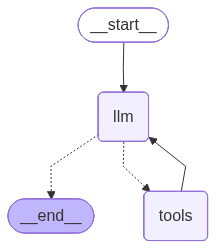

In [8]:
display(Image(rag_agent.get_graph().draw_mermaid_png()))

## 3. rész: Agent meghívása

A harmadik szekció a teljes rendszer interaktív működését valósítja meg: ez az a rész, ahol a felhasználó ténylegesen beszélget a RAG‑agent-tel, a háttérben pedig a LangGraph állapotgép fut, tool-okat hív, és több lépésben gondolkodik. Ez a szekció tehát a runtime, a chat loop, a felhasználói interfész.

#### 1. Configuration

`THREAD_ID = "exhibition_session_1"`:

Az aktuális futás egyedi azonosítója, aminek több felhasználó általi futtatás esetén lenne jelentősége. Mivel itt most nincs ilyenre szükség, ezért csak hardcode-oltam bele egy dummy id-t.

Ez egy egyszerű, de fontos elem:

- A LangGraph minden futtatást egy thread_id alatt tárol.

- Ez biztosítja, hogy a beszélgetés állapota (messages, memory) megmaradjon.

- Ha új thread_id‑t adok, új „beszélgetés” indul.

- Ha ugyanazt használom, a rendszer emlékszik a korábbi üzenetekre.

#### 2. Helper Functions

Itt segédfüggvényeket implementáltam annak érdekében, hogy a kód átláthatóbb és tagoltabb legyen.

`print_user_input(text: str)`:

- A felhasználói input megjelenítése, így a konzolon elkülönülnek a felhasználói és a rendszerüzenetek és átláthatóbb lesz a futás eredménye.

`print_execution_trace(event)`:

- Ez a rész nagyon fontos, mert megmutatja, hogy a LangGraph mely node‑ot futtatja éppen, láthatóvá teszi az agentic működést és demonstrálja, hogy a rendszer több lépésben gondolkodik.

- A trace nélkül a felhasználó nem látná, hogy a modell mikor hív tool-t, mikor gondolkodik, mikor generál választ.


`extract_final_answer(node_state)`:

Az utolsó válasz kinyerése:

- A LangGraph minden node‑ban egy messages listát tart fenn. 
- A utolsó válasz mindig az utolsó node utolsó üzenete, amely vagy az LLM válasza, vagy a tool eredménye.
- Ez a függvény ezt a logikát egyszerűsíti le.

`handle_error(error: Exception) -> bool`:

Ez a rész a rendszer stabilitását biztosítja. Kétféle hibát kezel:

- Rate limit / quota / túlterhelés esetén a modell túl sok kérést kapott, ezért várni kell, hogy frissüljön az LLM meghívásának a limitje.

- Egyéb hibák esetén a rendszer nem omlik össze, hanem szépen leáll.

#### 3. Main Chat Loop

Ez a harmadik szekció fő része, itt hívja meg a felhasználó az agentet.

A következő rész a felhasználói interakcióért felel: 

- elindítja a chatbotot, 

- bekéri a felhasználó kérdését, 

- kilépési lehetőséget biztosít,

- és a kérdést `HumanMessage` formátumba csomagolja, amit a LangGraph elvár. 

    def run_rag_chatbot():

        print("\n=== FREE AGENTIC RAG BOT (WITH MEMORY) ===")

        config = {"configurable": {"thread_id": THREAD_ID}}

        while True:
            user_input = input("\nWhat is your question (type 'exit' to quit): ").strip()

            if user_input.lower() in {"exit", "quit"}:
                break

            print_user_input(user_input)
            messages = [HumanMessage(content=user_input)]


A következő rész pedig az agent futtatását implementálja:

- A `rag_agent.stream()` elindítja a LangGraph állapotgépet.

- A `stream_mode="updates"` azt jelenti, hogy minden node futásáról értesítést kap a felhasználó.

- Minden event egy dictionary, amely tartalmazza, hogy melyik node futott és annak mi az aktuális állapota.

- A `last_state` mindig a legutolsó node állapotát tartalmazza.

- Végül kiveszi a rendszer a végső választ és megjeleníti a felhasználónak.

        try:
            print("\n⏳ Agent Execution Trace:")

            last_state = None
            for event in rag_agent.stream({"messages": messages}, config, stream_mode="updates"):
                last_state = list(event.values())[-1]
                print_execution_trace(event)

            final_answer = extract_final_answer(last_state)
            print(f"\n=== 🤖 FINAL ANSWER ===\n{final_answer}")

        except Exception as e:
            if not handle_error(e):
                break

A trace nélkül a LangGraph működése rejtve maradna.

### Összegzés

A harmadik szekció a teljes RAG‑agent interaktív futtatását valósítja meg.

Ez a rész felel:

- a felhasználói input kezeléséért,

- a LangGraph agent futtatásáért,

- a node‑szintű trace megjelenítéséért,

- a végső válasz kinyeréséért,

- a hibakezelésért,

- és a beszélgetés állapotának fenntartásáért.

Így alkot a három szekció együtt egy teljes, agentic RAG‑rendszert.


In [4]:
# ---------------------------------------------------------
# 1. Configuration
# ---------------------------------------------------------

THREAD_ID = "exhibition_session_1"


# ---------------------------------------------------------
# 2. Helper Functions
# ---------------------------------------------------------

def print_user_input(text: str):
    print("\n=== 👤 USER INPUT ===")
    print(text)


def print_execution_trace(event):
    for node_name in event.keys():
        print(f"   🔄 Currently running node: [{node_name}]")


def extract_final_answer(node_state):
    return node_state["messages"][-1].content


def handle_error(error: Exception) -> bool:
    """Return True to continue the loop, False to stop."""
    
    message = str(error)

    print("\n=== SYSTEM MESSAGE ===")

    if "429" in message or "RESOURCE_EXHAUSTED" in message:
        print("The model reached its usage limit. Please wait 30–60 seconds and try again.")
        return True

    print(f"An unexpected error occurred: {message}")
    return False


# ---------------------------------------------------------
# 3. Main Chat Loop
# ---------------------------------------------------------

def run_rag_chatbot():
    print("\n=== FREE AGENTIC RAG BOT (WITH MEMORY) ===")

    config = {"configurable": {"thread_id": THREAD_ID}}

    while True:
        user_input = input("\nWhat is your question (type 'exit' to quit): ").strip()

        if user_input.lower() in {"exit", "quit"}:
            break

        print_user_input(user_input)
        messages = [HumanMessage(content=user_input)]

        try:
            print("\n⏳ Agent Execution Trace:")

            last_state = None
            for event in rag_agent.stream({"messages": messages}, config, stream_mode="updates"):
                last_state = list(event.values())[-1]
                print_execution_trace(event)

            final_answer = extract_final_answer(last_state)
            print(f"\n=== 🤖 FINAL ANSWER ===\n{final_answer}")

        except Exception as e:
            if not handle_error(e):
                break


In [5]:
run_rag_chatbot()


=== FREE AGENTIC RAG BOT (WITH MEMORY) ===

=== 👤 USER INPUT ===
what's the weather like today in Budapest?

⏳ Agent Execution Trace:


Impersonate 'firefox_128' does not exist, using 'random'


   🔄 Currently running node: [llm]

🌐 [TOOL ACTIVATED] Searching the web for: 'weather today in Budapest'
   🔄 Currently running node: [tools]
   🔄 Currently running node: [llm]

=== 🤖 FINAL ANSWER ===
Based on a web search, today's weather in Budapest includes current conditions, wind, air quality, and a forecast for the next three days. You can also find a detailed 14-day outlook, hourly sky color tracking, and historical climate data. The forecast includes temperature, wind, rain, snow, and UV index. There are also live weather reports and warnings for potential risks like thunder and high UV index.

=== 👤 USER INPUT ===
how was smp500 performing in 2024?

⏳ Agent Execution Trace:
   🔄 Currently running node: [llm]

📄 [TOOL ACTIVATED] Searching PDF for: 'SMP500 performance in 2024'
   🔄 Currently running node: [tools]
   🔄 Currently running node: [llm]

=== 🤖 FINAL ANSWER ===
According to the PDF, the S&P 500 performed very strongly in 2024, with a total return of approximately 25%.

## A rendszer működése röviden

1. A felhasználó beír egy kérdést.

2. A LangGraph LLM node‑ja megkapja a kérdést + system prompt-ot.

3. Az LLM eldönti:
- kell‑e retriever_tool?
- vagy web_search_tool?
- vagy tud válaszolni saját tudásból?

4. Ha tool kell, akkor a Tools node fut.

5. A tool eredménye visszakerül az LLM‑hez.

6. Az LLM megfogalmazza a végső választ.

7. A chat loop megjeleníti.

8. A MemorySaver elmenti a beszélgetést.


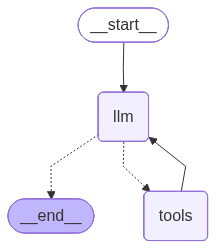

In [10]:
display(Image(rag_agent.get_graph().draw_mermaid_png()))

# Bottleneck-ek és a javítási lehetőségeik

### Adatfeldolgozás korlátoltsága

Jelenleg csak PDF-et tud beolvasni a rendszer, ez alapvetően egy szűkösséget, rugalmatlanságot ad, mivel így egyéb fájltípusú adatforrásokat nem tud feldolgozni. Ezt megpróbáltam kiküszöbölni, de bizonytalanabbul működöt a modell, ezért maradtam a PDF-eknél.

A következő kódrészlet az, ahogyan a többféle fájltípus beolvasására képes változatot csináltam (de ezt végül elvetettem):

    def load_documents_dynamically(data_dir: str):
        """Scans the directory and uses the correct loader based on file extension."""

        documents = []

        # Check for PDFs
        for file_path in glob.glob(os.path.join(data_dir, "*.pdf")):
            print(f"Loading PDF: {file_path}")
            loader = PyPDFLoader(file_path)
            documents.extend(loader.load())

        # Check for CSVs
        for file_path in glob.glob(os.path.join(data_dir, "*.csv")):
            print(f"Loading CSV: {file_path}")
            loader = CSVLoader(file_path)
            documents.extend(loader.load())

        return documents


### A MiniLM embedding modell CPU‑n fut

- A MiniLM ugyan gyors, de CPU‑n futtatva chunkonként 20–40 ms is lehet az embedding sebessége, ez nagy dokumentumoknál összeadódik, és végeredményben lassú lehet a beágyazás és így a vektoradatbázis elkészítése, ráadáasul GPU-val való gyorsításra sincs lehetőség itt.

- Ezen lehetne javítani GPU‑gyorsított SentenceTransformer modellek vagy API‑alapú embedding-ek (OpenAI, Gemini, Cohere) által.

### Több felhasználó egy időben való kiszolgálására nem képes a modellem

- Jelenleg lokális Qdrant adatbázist használok, a chat loop egy szálon fut, és a tool-ok sem képesek aszinkron futásra, ha egy meg lett hívva, akkor azt szépen megvárja az llm, és utána következik a következő lépés. Ezek mind azt eredményezik, hogy a jelenlegi modellem nem lenne képes több felhasználó egyidejű kiszolgálására.

- Ezen lehetne fejleszteni cloud alapú Qdrant-tal, cache-eléssel (ami több felhasználó ugyanazt vagy nagyon hasonló kérdésének a megválaszolását gyorsítaná), valamint aszinkron retriever bevezetésével (ezzel több retriever hívás egyszerre futtatható lenne).

### A PDF chunkolása statikus

- Mivel A `CHUNK_SIZE` és a `CHUNK_OVERLAP` is fix érték, ezért ez nem veszi figyelembe a dokumentum szerkezetét, és néha túl nagy vagy túl kicsi chunkokat eredményez, így a retriever pontossága csökkenhet.

- Ezen strukturált chunk-olással (fejezetek, alcímek alapján), szemantikus chunk-olással, vagy hierarchikus RAG modellel lehetne javítani.

### web_search tool alacsonyabb hatékonysága

- A DuckDuckGo kereső ugyan egyszerűen és biztonságosan használható, de teljesítményben vannak nála jobbak és megbízhatóbbak. Ez ugyanis változó válaszidővel működik, néha lassú vagy rate-limited és nem determinisztikus.

- Ezen stabilabb webes kereső API-okkal lehetne javítani (például SerpAPI, Tavily, Bing Search API).



# További fejlesztési lehetőségek

### Architektúra szerinti továbbfejlesztés

A jelenlegi modell egy egyszerű single-agent modell, mégpedig a hagyományos tool-augmented single agent: egyetlen döntéshozó LLM van, az a rendszer "agya", és az ő kezében van mindig a következő lépés, hogy hova lépjen a gráfon belül (kell-e tool-t hívnia, vagy anélkül is tud válaszolni).

Továbbfejleszhető lenne viszont a következő RAG modellekre:

- Multi-modal RAG: Ez PDF + képek + táblázatok + grafikonok feldolgozására is képes lenne, valamint vision‑LLM integrációra is akár (Gemini Vision, GPT‑4o, Claude 3 Opus).

- Hierarchikus RAG (HRAG): Ennél először fejezet szintű keresés, majd chunk szintű finomítás, végül LLM reasoning történne, így sokkal pontosabb és skálázhatóbb keresést tenne lehetővé.

- Multi-agent RAG: Ebben több agent venne részt, mindegyiknek egy-egy részfeladata lenne, és mindegyik mögött lehetne az adott feladatra a legmegfelelőbb LLM hozzárendelve. Az agent-ek a feladatokat megoszthatnák például úgy, hogy egyik a keresésért felelne, másik a reasoning-ért, harmadik a válasz formázásáért, negyedik a tool‑hívások optimalizálásáért. Ez egy jóval bonyolultabb moduláris rendszer lenne, de sokkal-sokkal robosztusabb, megbízhatóbb, nagyteljesítményűbb (és persze erőforrás-igényesebb).

### Teljes pipeline automatizálása

Ezzel lehetővé válnának a dokumentumok automatikus feldolgozása, a verziókezelés és a monitoring + logging + observability.

### Long-term memory

Hozzáadható lenne long-term memory, így az agent a későbbi meghíváskor is emlékezne a korábbi beszélgetésre. Ez a memória nem a modellben él, hanem egy külön adatbázisban (pl. Qdrant, SQLite, Redis, Postgres). A modell minden kérdésnél lekérdezi a long‑term memoryt, a releváns elemeket visszakapja, majd ezeket beépíti a promptba, így személyre szabottabb és kontextus‑gazdagabb választ ad.

### Fine‑tuning / RAG‑tuning

Az embedding model finetune-olható lenne saját domain-re, az LLM a toolhasználatra, hibrid keresés hozzáadható lehetne (szemantikus + keyword szerinti keresés), más chunking strategy lehetne (akár dinamikus chunk size vagy chunk overlap).
Ez ötvözhető lenne például egy olyan multi-agent rendszerrel, ahol minden agent LLM-je finomhangolva van az adott feladatára, így jelentősen növelni lehetne a modell hatékonyságát.

### Biztonság és minőségbiztosítás

Guardrail implementálható lenne (egy példa: https://www.nb-data.com/p/building-guardrail-around-your-rag):

- prompt injection elleni védelem
- tool‑használat validálása
- output‑filtering (toxicitás, hallucination detection)


# A modell teljesíményének a tesztelése és mérése

A teljesítmény mérését és tesztelését három külön rétegben érdemes megközelíteni: 

1. a RAG‑pipeline komponensei

2. az agentic LangGraph‑logika

3. a felhasználói élmény és válaszidő

Ezek mind különféle metrikákat és tesztelési módszereket igényelnek.

## A RAG‑pipeline komponenseinek teljesítménymérése

#### Embedding sebesség

A dokumentum feldolgozásakor érdemes mérni egy chunk embedding-jének az idejét, a teljes PDF embedding-jének az idejét és a CPU‑terhelést. Ez megmutatja, hogy a MiniLM modell mennyire gyors az adott CPU-n.

#### Chunk-olás hatékonysága

A chunk-olás minősége közvetlenül befolyásolja a retriever pontosságát. Mérhető az átlagos chunk méret, a chunk-ok száma, az átfedések aránya,
chunk‑szintű redundancia. Ezek alapján optimalizálható a chunk_size és chunk_overlap.

#### Vektortár keresési teljesítménye

A vektoradatbázisban érdemes mérni a similarity search latency-t (ms), index méretét, a memóriahasználatot, a keresési pontosságot (recall@k). A recall@k méréséhez manuálisan kiválasztott kérdésekre ellenőrizhető, hogy a retriever valóban releváns chunk-okat ad‑e vissza. (példa: https://towardsdatascience.com/how-to-evaluate-retrieval-quality-in-rag-pipelines-precisionk-recallk-and-f1k/)

## Az agentic LangGraph működésének tesztelése

#### Tool‑hívások helyessége

Ez a legfontosabb agentic metrika: a modell mikor és milyen pontossággal hívja a megfelelő toolt?

Mérhető a tool_call accuracy (helyes tool választása), az unnecessary tool calls aránya, valamint a tool‑call hibák (pl. üres eredmény). Ez különösen fontos, mert a modell két toolt használ, és a LLM‑nek kell eldöntenie, hogy melyik szükséges.

#### Node‑szintű késleltetés

A LangGraph két node‑ot futtat: LLM node, Tools node. Mérhető így az LLM node latency, a Tools node latency, a teljes agent execution time. Ez megmutatja, hogy a rendszer melyik része a szűk keresztmetszet.

#### Állapotkezelés tesztelése

A MemorySaver miatt fontos ellenőrizni, hogy a beszélgetés állapota helyesen halmozódik‑e, a reducer (add_messages) nem duplikál‑e üzeneteket, és a thread_id alapján valóban külön szálak jönnek létre.

## A felhasználói élmény és válaszidő mérése

#### End‑to‑end latency

Ez a legfontosabb UX metrika: a felhasználó kérdésétől a végső válaszig eltelt idő. Ez tartalmazza az LLM gondolkodási idejét, a tool‑hívások idejét, a retriever keresési idejét és a LangGraph overhead-et.

#### Stabilitás és hibakezelés

Tesztelhető az is, hogy hogyan reagál a rendszer rate limit esetén, hogyan kezeli a web search hibáit, és hogyan viselkedik üres vagy irreleváns kérdéseknél.

#### Hallucináció tesztelése

A RAG rendszerek egyik legfontosabb tesztje: a modell ne találjon ki PDF‑ben nem szereplő információt, a web search eredményeit helyesen használja, a válaszokban szereplő állítások visszavezethetők legyenek forrásra.

#### Relevancia tesztelése

Készíthető egy tesztkészlet: 20–50 kérdés a PDF tartalmából, 20–50 kérdés a PDF‑en kívüli témákból. Mérhető így a helyes tool választás, a releváns chunkok visszaadása, a válasz pontossága és a forrásmegjelölés helyessége.


## Összegzés

A teljesítmény mérését tehát három szinten érdemes végezni:

1. RAG‑pipeline: embedding, chunkolás, retriever, vektortár

2. Agentic logika: tool‑call pontosság, node‑latency, állapotkezelés

3. Felhasználói élmény: end‑to‑end latency, stabilitás, relevancia

Ezek együtt adják a rendszer valódi minőségét és megbízhatóságát.
